# ===== ШАГ 1. ЗАГРУЗКА ДАННЫХ =====

In [13]:
# ===== ШАГ 1. ЗАГРУЗКА ДАННЫХ =====
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

import warnings
warnings.filterwarnings('ignore')

# Загрузка главного файла
df = pd.read_csv('application_train.csv')

print(f"✅ Датасет загружен!")
print(f"📊 Строк: {df.shape[0]:,}")
print(f"📋 Колонок: {df.shape[1]}")
print(f"\n🎯 Целевая переменная (TARGET):")
print(df['TARGET'].value_counts())
print(f"\nДоля дефолтов: {df['TARGET'].mean():.2%}")

✅ Датасет загружен!
📊 Строк: 307,511
📋 Колонок: 122

🎯 Целевая переменная (TARGET):
TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.07%


# ===== ШАГ 2. ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ =====

In [14]:
# ===== ШАГ 2. ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ =====

# 2.1 Первый взгляд на данные
print("=" * 50)
print("ПЕРВЫЕ 5 СТРОК:")
print("=" * 50)
df.head()

ПЕРВЫЕ 5 СТРОК:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# 2.2 Размер и типы данных
print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())

Размер датасета: (307511, 122)

Типы данных:
float64    65
int64      41
object     16
Name: count, dtype: int64


🎯 TARGET распределение:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.07%


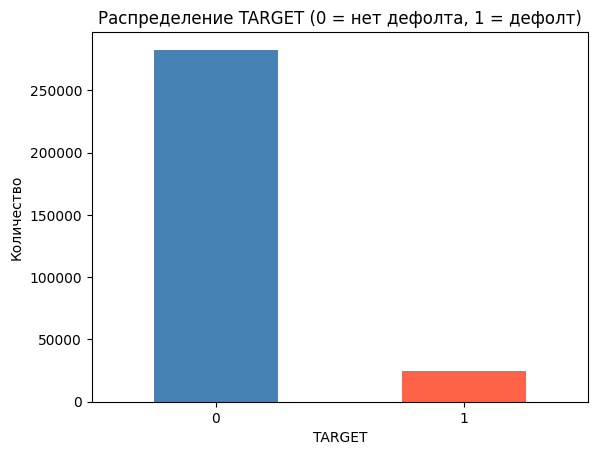

In [16]:
# 2.3 Целевая переменная
print("🎯 TARGET распределение:")
print(df['TARGET'].value_counts())
print(f"\nДоля дефолтов: {df['TARGET'].mean():.2%}")

# Визуализация
df['TARGET'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Распределение TARGET (0 = нет дефолта, 1 = дефолт)')
plt.xticks(rotation=0)
plt.ylabel('Количество')
plt.show()

In [17]:
# 2.4 Базовая статистика числовых колонок
print("📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК:")
df.describe().T

📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [18]:
# 2.5 Сколько категориальных vs числовых колонок
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"🔢 Числовых колонок: {len(num_cols)}")
print(f"🔤 Категориальных колонок: {len(cat_cols)}")
print(f"\nКатегориальные колонки:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} уникальных значений")

🔢 Числовых колонок: 106
🔤 Категориальных колонок: 16

Категориальные колонки:
  NAME_CONTRACT_TYPE: 2 уникальных значений
  CODE_GENDER: 3 уникальных значений
  FLAG_OWN_CAR: 2 уникальных значений
  FLAG_OWN_REALTY: 2 уникальных значений
  NAME_TYPE_SUITE: 7 уникальных значений
  NAME_INCOME_TYPE: 8 уникальных значений
  NAME_EDUCATION_TYPE: 5 уникальных значений
  NAME_FAMILY_STATUS: 6 уникальных значений
  NAME_HOUSING_TYPE: 6 уникальных значений
  OCCUPATION_TYPE: 18 уникальных значений
  WEEKDAY_APPR_PROCESS_START: 7 уникальных значений
  ORGANIZATION_TYPE: 58 уникальных значений
  FONDKAPREMONT_MODE: 4 уникальных значений
  HOUSETYPE_MODE: 3 уникальных значений
  WALLSMATERIAL_MODE: 7 уникальных значений
  EMERGENCYSTATE_MODE: 2 уникальных значений


# ===== ШАГ 3. РАБОТА С ПРОПУСКАМИ =====

In [19]:
# ===== ШАГ 3. РАБОТА С ПРОПУСКАМИ =====

# Общая картина пропусков
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

missing_df

,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
...,...,...
EXT_SOURCE_2,660,0.21
AMT_GOODS_PRICE,278,0.09
AMT_ANNUITY,12,0.00
CNT_FAM_MEMBERS,2,0.00


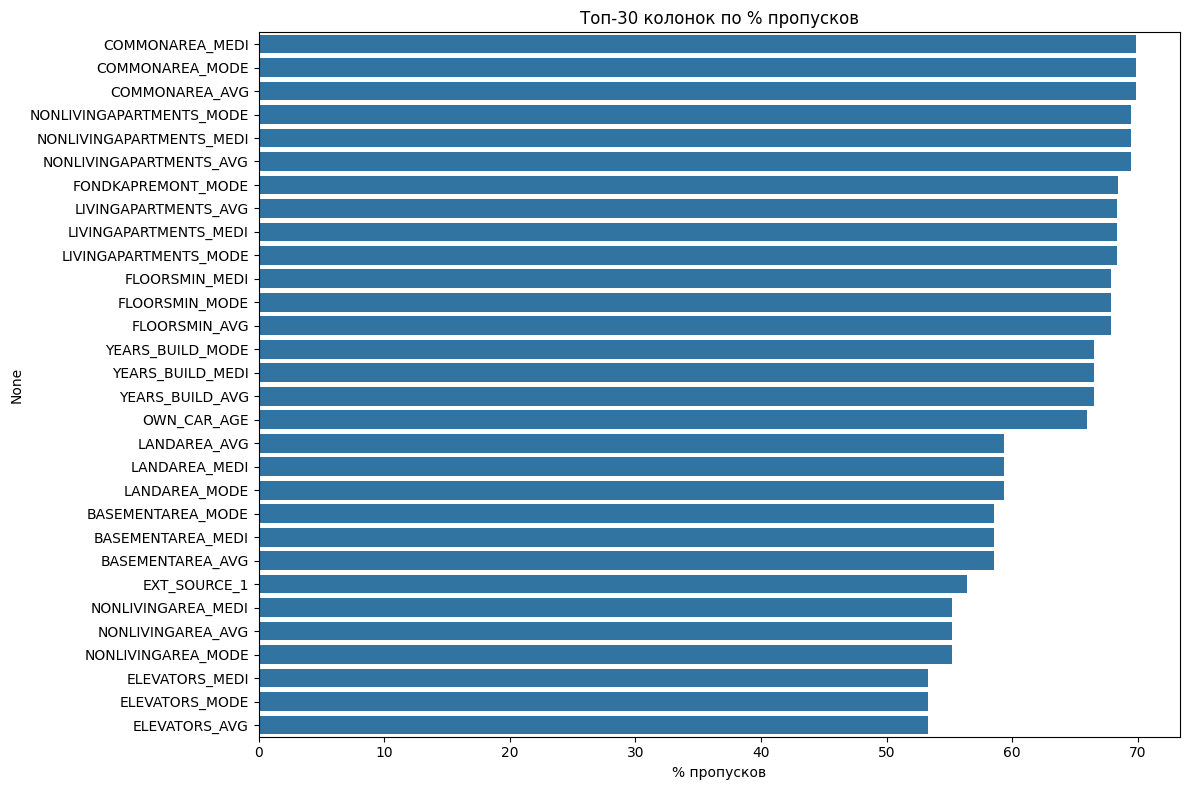

In [20]:
# Визуализация топ-30 колонок с пропусками
top_missing = missing_df.head(30)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_missing['missing_pct'], y=top_missing.index)
plt.title('Топ-30 колонок по % пропусков')
plt.xlabel('% пропусков')
plt.tight_layout()
plt.show()

In [21]:
# Удаляем колонки где > 45% пропусков
threshold = 45
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

print(f"Удалено колонок: {len(cols_to_drop)}")
print(f"Осталось колонок: {df.shape[1]}")

Удалено колонок: 49
Осталось колонок: 73


In [22]:
# Заполняем пропуски
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Числовые → медиана
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Категориальные → 'Unknown'
df[cat_cols] = df[cat_cols].fillna('Unknown')

# Проверка
df.isnull().sum().sum()  # должно быть 0

np.int64(0)

In [24]:
df.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 73, dtype: int64

In [37]:
# Перезагружаем чистый датафрейм
df = pd.read_csv('application_train.csv')

# Повторяем шаг 3 (пропуски)
missing_pct = (df.isnull().sum() / len(df) * 100)
cols_to_drop = missing_pct[missing_pct > 45].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('Unknown')

df.isnull().sum().sum()  # должно быть 0

np.int64(0)

# **===== ШАГ 4. EDA =====**

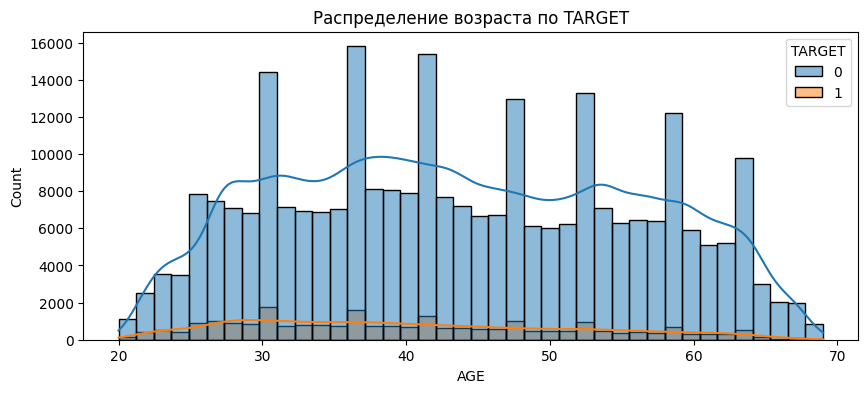

In [25]:
# ===== ШАГ 4. EDA =====

# 4.1 Распределение возраста (DAYS_BIRTH → годы)
df['AGE'] = (df['DAYS_BIRTH'] / -365).astype(int)

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='AGE', hue='TARGET', bins=40, kde=True)
plt.title('Распределение возраста по TARGET')
plt.show()

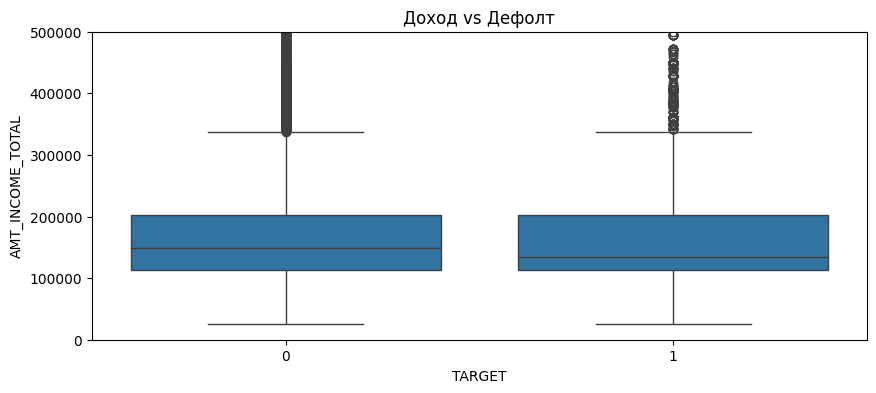

In [26]:
# 4.2 Доход vs Дефолт
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='TARGET', y='AMT_INCOME_TOTAL')
plt.ylim(0, 500000)  # убираем выбросы для читаемости
plt.title('Доход vs Дефолт')
plt.show()

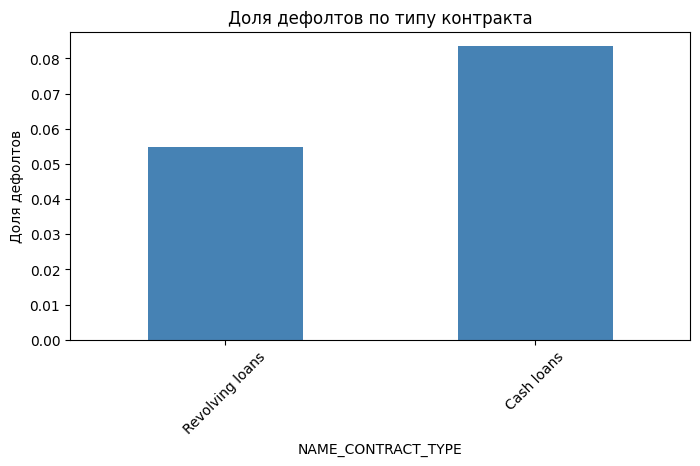

In [27]:
# 4.3 Дефолт по типу контракта
df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean().sort_values().plot(
    kind='bar', color='steelblue', figsize=(8, 4)
)
plt.title('Доля дефолтов по типу контракта')
plt.ylabel('Доля дефолтов')
plt.xticks(rotation=45)
plt.show()

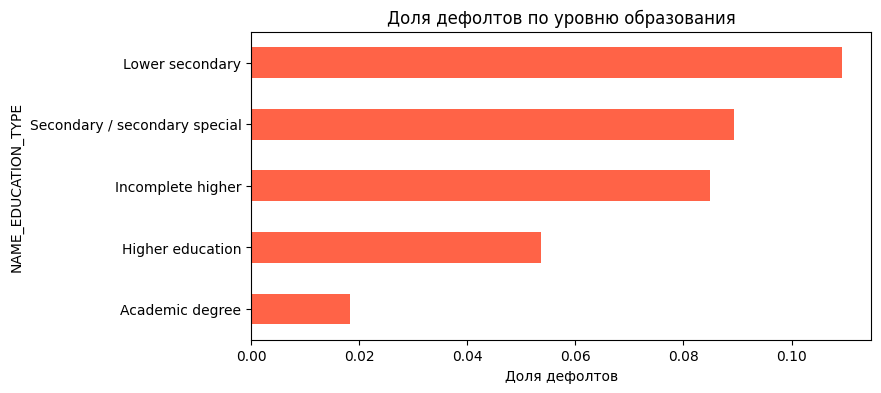

In [28]:
# 4.4 Дефолт по уровню образования
df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values().plot(
    kind='barh', color='tomato', figsize=(8, 4)
)
plt.title('Доля дефолтов по уровню образования')
plt.xlabel('Доля дефолтов')
plt.show()

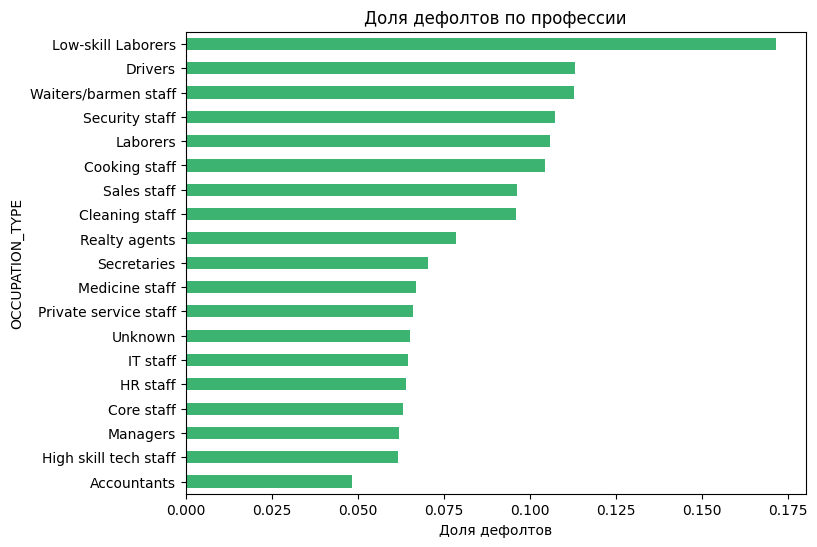

In [29]:
# 4.5 Дефолт по типу занятости
df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values().plot(
    kind='barh', color='mediumseagreen', figsize=(8, 6)
)
plt.title('Доля дефолтов по профессии')
plt.xlabel('Доля дефолтов')
plt.show()

# **===== ШАГ 5. ENCODING =====**

In [38]:
# Смотрим все категориальные колонки и сколько уникальных значений
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

NAME_CONTRACT_TYPE: ['Cash loans' 'Revolving loans']
CODE_GENDER: ['M' 'F' 'XNA']
FLAG_OWN_CAR: ['N' 'Y']
FLAG_OWN_REALTY: ['Y' 'N']
NAME_TYPE_SUITE: ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' 'Unknown'
 'Other_B' 'Group of people']
NAME_INCOME_TYPE: ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
NAME_EDUCATION_TYPE: ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS: ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']
NAME_HOUSING_TYPE: ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment']
OCCUPATION_TYPE: ['Laborers' 'Core staff' 'Accountants' 'Managers' 'Unknown' 'Drivers'
 'Sales staff' 'Cleaning staff' 'Cooking staff' 'Private service staff'
 'Medicine staff' 'Security staff' 'High skill tech staff'
 'Waiters/barmen staf

In [39]:
# ===== ШАГ 5. ENCODING =====

# 1. Удаляем XNA в CODE_GENDER (это 4 строки, не критично)
df = df[df['CODE_GENDER'] != 'XNA']

# 2. Replace для бинарных
df['NAME_CONTRACT_TYPE'].replace(['Cash loans', 'Revolving loans'], [0, 1], inplace=True)
df['CODE_GENDER'].replace(['M', 'F'], [0, 1], inplace=True)
df['FLAG_OWN_CAR'].replace(['N', 'Y'], [0, 1], inplace=True)
df['FLAG_OWN_REALTY'].replace(['N', 'Y'], [0, 1], inplace=True)

# 3. OneHot для остальных
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Проверка
df.dtypes.value_counts()

bool       109
int64       45
float64     20
Name: count, dtype: int64

# **===== ШАГ 6. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ =====**

In [41]:
# ===== ШАГ 6. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ =====

# bool колонки конвертируем в int для корреляции
df_corr = df.copy()
bool_cols = df_corr.select_dtypes(include='bool').columns
df_corr[bool_cols] = df_corr[bool_cols].astype(int)

# Топ-15 признаков коррелирующих с TARGET
corr_target = df_corr.corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
corr_target.head(15)

EXT_SOURCE_2                                         0.160294
EXT_SOURCE_3                                         0.155899
DAYS_BIRTH                                           0.078242
REGION_RATING_CLIENT_W_CITY                          0.060895
REGION_RATING_CLIENT                                 0.058901
NAME_INCOME_TYPE_Working                             0.057483
NAME_EDUCATION_TYPE_Higher education                 0.056593
DAYS_LAST_PHONE_CHANGE                               0.055219
CODE_GENDER                                          0.054710
DAYS_ID_PUBLISH                                      0.051457
REG_CITY_NOT_WORK_CITY                               0.050992
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049822
NAME_INCOME_TYPE_Pensioner                           0.046211
ORGANIZATION_TYPE_XNA                                0.045989
FLAG_EMP_PHONE                                       0.045984
Name: TARGET, dtype: float64

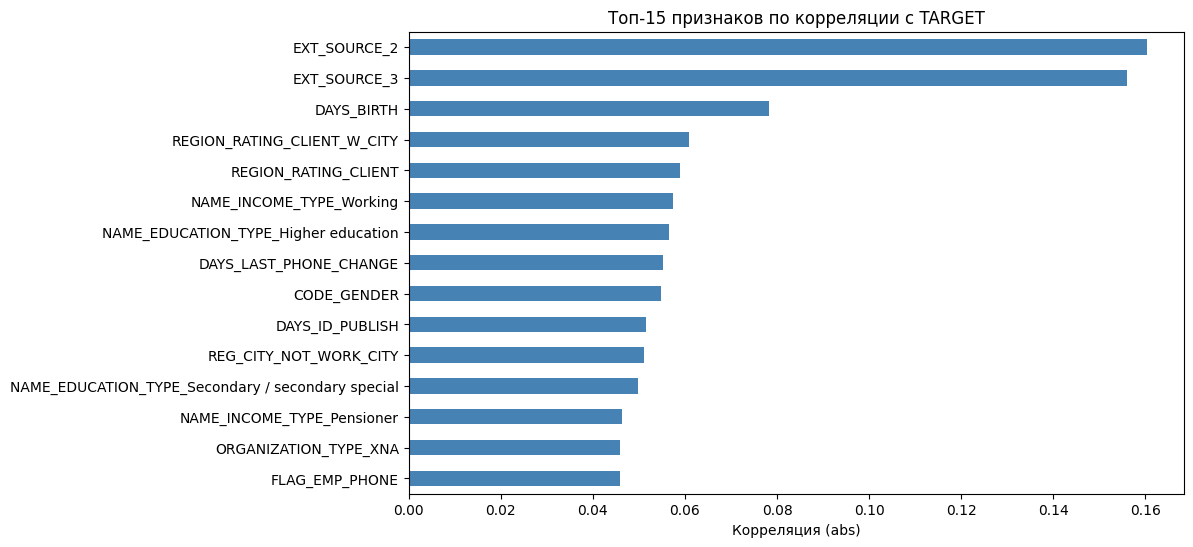

In [42]:
# Визуализация
corr_target.head(15).plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Топ-15 признаков по корреляции с TARGET')
plt.xlabel('Корреляция (abs)')
plt.gca().invert_yaxis()
plt.show()

# **===== ШАГ 7. ПЕРЕМЕННЫЕ X и Y =====****

In [43]:
# ===== ШАГ 7. ПЕРЕМЕННЫЕ X и Y =====

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

Y = df['TARGET']
X = df.drop(columns=['TARGET'])

X.shape, Y.shape

((307507, 173), (307507,))

# **===== ШАГ 8. TRAIN / TEST SPLIT =====**

In [44]:
# ===== ШАГ 8. TRAIN / TEST SPLIT =====

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

X_train.shape, X_test.shape

((246005, 173), (61502, 173))

# **===== ШАГ 9. ОБУЧЕНИЕ МОДЕЛИ =====**

In [45]:
# ===== ШАГ 9. ОБУЧЕНИЕ МОДЕЛИ =====

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Логистическая регрессия (быстрая, базовая)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, Y_train)

lr_pred = lr.predict_proba(X_test)[:, 1]
print(f"Logistic Regression ROC-AUC: {roc_auc_score(Y_test, lr_pred):.4f}")

Logistic Regression ROC-AUC: 0.6298


In [46]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)

rf_pred = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(Y_test, rf_pred):.4f}")

Random Forest ROC-AUC: 0.7139


# **===== ШАГ 10. ТЕСТИРОВАНИЕ МОДЕЛИ =====**

In [47]:
# ===== ШАГ 10. ТЕСТИРОВАНИЕ МОДЕЛИ =====

from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# Classification report
rf_class = rf.predict(X_test)
print(classification_report(Y_test, rf_class))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56537
           1       0.86      0.00      0.00      4965

    accuracy                           0.92     61502
   macro avg       0.89      0.50      0.48     61502
weighted avg       0.91      0.92      0.88     61502



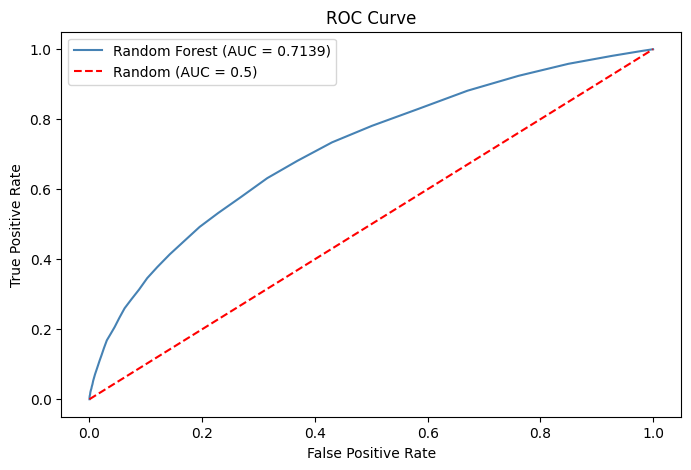

In [48]:
# ROC кривая
fpr, tpr, _ = roc_curve(Y_test, rf_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'Random Forest (AUC = 0.7139)')
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

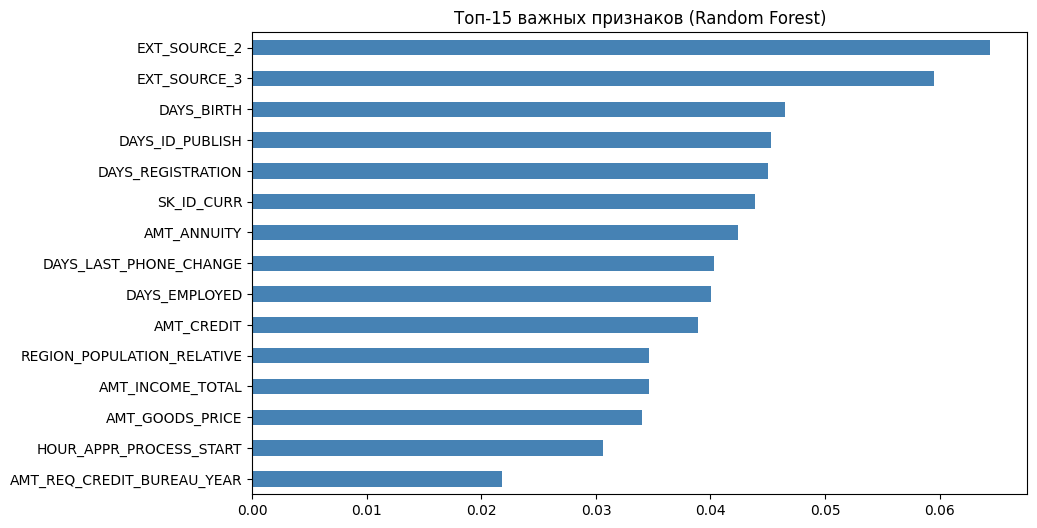

In [49]:
# Feature Importance — топ 15 важных признаков
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.title('Топ-15 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [50]:
# Переобучаем с балансировкой
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # вот это решает проблему
)
rf_balanced.fit(X_train, Y_train)

rf_bal_pred = rf_balanced.predict_proba(X_test)[:, 1]
rf_bal_class = rf_balanced.predict(X_test)

print(f"ROC-AUC: {roc_auc_score(Y_test, rf_bal_pred):.4f}")
print()
print(classification_report(Y_test, rf_bal_class))

ROC-AUC: 0.7239

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56537
           1       0.80      0.00      0.00      4965

    accuracy                           0.92     61502
   macro avg       0.86      0.50      0.48     61502
weighted avg       0.91      0.92      0.88     61502



In [51]:
# По умолчанию порог = 0.5, но дефолтников мало
# Снижаем до 0.3
threshold = 0.3
rf_bal_class_new = (rf_bal_pred >= threshold).astype(int)

print(f"Порог: {threshold}")
print(classification_report(Y_test, rf_bal_class_new))

Порог: 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56537
           1       0.36      0.05      0.09      4965

    accuracy                           0.92     61502
   macro avg       0.64      0.52      0.52     61502
weighted avg       0.88      0.92      0.89     61502



In [52]:
# Найдём оптимальный порог через ROC кривую
fpr, tpr, thresholds = roc_curve(Y_test, rf_bal_pred)

# Оптимальный порог = максимальный (tpr - fpr)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Оптимальный порог: {optimal_threshold:.4f}")

optimal_preds = (rf_bal_pred >= optimal_threshold).astype(int)
print(classification_report(Y_test, optimal_preds))

Оптимальный порог: 0.0900
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56537
           1       0.15      0.67      0.25      4965

    accuracy                           0.67     61502
   macro avg       0.55      0.67      0.52     61502
weighted avg       0.89      0.67      0.74     61502



# **===== СОХРАНЕНИЕ МОДЕЛИ =====**

In [ ]:
# ===== СОХРАНЕНИЕ МОДЕЛИ =====
import joblib

joblib.dump(rf_balanced, 'credit_scoring_model.pkl')
joblib.du✅ Датасет загружен!
📊 Строк: 307,511
📋 Колонок: 122

🎯 Целевая переменная (TARGET):
TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.07%
==================================================
ПЕРВЫЕ 5 СТРОК:
==================================================
SK_ID_CURR	TARGET	NAME_CONTRACT_TYPE	CODE_GENDER	FLAG_OWN_CAR	FLAG_OWN_REALTY	CNT_CHILDREN	AMT_INCOME_TOTAL	AMT_CREDIT	AMT_ANNUITY	...	FLAG_DOCUMENT_18	FLAG_DOCUMENT_19	FLAG_DOCUMENT_20	FLAG_DOCUMENT_21	AMT_REQ_CREDIT_BUREAU_HOUR	AMT_REQ_CREDIT_BUREAU_DAY	AMT_REQ_CREDIT_BUREAU_WEEK	AMT_REQ_CREDIT_BUREAU_MON	AMT_REQ_CREDIT_BUREAU_QRT	AMT_REQ_CREDIT_BUREAU_YEAR
0	100002	1	Cash loans	M	N	Y	0	202500.0	406597.5	24700.5	...	0	0	0	0	0.0	0.0	0.0	0.0	0.0	1.0
1	100003	0	Cash loans	F	N	N	0	270000.0	1293502.5	35698.5	...	0	0	0	0	0.0	0.0	0.0	0.0	0.0	0.0
2	100004	0	Revolving loans	M	Y	Y	0	67500.0	135000.0	6750.0	...	0	0	0	0	0.0	0.0	0.0	0.0	0.0	0.0
3	100006	0	Cash loans	F	N	Y	0	135000.0	312682.5	29686.5	...	0	0	0	0	NaN	NaN	NaN	NaN	NaN	NaN
4	100007	0	Cash loans	M	N	Y	0	121500.0	513000.0	21865.5	...	0	0	0	0	0.0	0.0	0.0	0.0	0.0	0.0
5 rows × 122 columns

Размер датасета: (307511, 122)

Типы данных:
float64    65
int64      41
object     16
Name: count, dtype: int64
🎯 TARGET распределение:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Доля дефолтов: 8.07%
📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК:
count	mean	std	min	25%	50%	75%	max
SK_ID_CURR	307511.0	278180.518577	102790.175348	100002.0	189145.5	278202.0	367142.5	456255.0
TARGET	307511.0	0.080729	0.272419	0.0	0.0	0.0	0.0	1.0
CNT_CHILDREN	307511.0	0.417052	0.722121	0.0	0.0	0.0	1.0	19.0
AMT_INCOME_TOTAL	307511.0	168797.919297	237123.146279	25650.0	112500.0	147150.0	202500.0	117000000.0
AMT_CREDIT	307511.0	599025.999706	402490.776996	45000.0	270000.0	513531.0	808650.0	4050000.0
...	...	...	...	...	...	...	...	...
AMT_REQ_CREDIT_BUREAU_DAY	265992.0	0.007000	0.110757	0.0	0.0	0.0	0.0	9.0
AMT_REQ_CREDIT_BUREAU_WEEK	265992.0	0.034362	0.204685	0.0	0.0	0.0	0.0	8.0
AMT_REQ_CREDIT_BUREAU_MON	265992.0	0.267395	0.916002	0.0	0.0	0.0	0.0	27.0
AMT_REQ_CREDIT_BUREAU_QRT	265992.0	0.265474	0.794056	0.0	0.0	0.0	0.0	261.0
AMT_REQ_CREDIT_BUREAU_YEAR	265992.0	1.899974	1.869295	0.0	0.0	1.0	3.0	25.0
106 rows × 8 columns

🔢 Числовых колонок: 106
🔤 Категориальных колонок: 16

Категориальные колонки:
  NAME_CONTRACT_TYPE: 2 уникальных значений
  CODE_GENDER: 3 уникальных значений
  FLAG_OWN_CAR: 2 уникальных значений
  FLAG_OWN_REALTY: 2 уникальных значений
  NAME_TYPE_SUITE: 7 уникальных значений
  NAME_INCOME_TYPE: 8 уникальных значений
  NAME_EDUCATION_TYPE: 5 уникальных значений
  NAME_FAMILY_STATUS: 6 уникальных значений
  NAME_HOUSING_TYPE: 6 уникальных значений
  OCCUPATION_TYPE: 18 уникальных значений
  WEEKDAY_APPR_PROCESS_START: 7 уникальных значений
  ORGANIZATION_TYPE: 58 уникальных значений
  FONDKAPREMONT_MODE: 4 уникальных значений
  HOUSETYPE_MODE: 3 уникальных значений
  WALLSMATERIAL_MODE: 7 уникальных значений
  EMERGENCYSTATE_MODE: 2 уникальных значений
missing_count	missing_pct
COMMONAREA_MEDI	214865	69.87
COMMONAREA_MODE	214865	69.87
COMMONAREA_AVG	214865	69.87
NONLIVINGAPARTMENTS_MODE	213514	69.43
NONLIVINGAPARTMENTS_MEDI	213514	69.43
...	...	...
EXT_SOURCE_2	660	0.21
AMT_GOODS_PRICE	278	0.09
AMT_ANNUITY	12	0.00
CNT_FAM_MEMBERS	2	0.00
DAYS_LAST_PHONE_CHANGE	1	0.00
67 rows × 2 columns

Удалено колонок: 49
Осталось колонок: 73
np.int64(0)
SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 73, dtype: int64
np.int64(0)
NAME_CONTRACT_TYPE: ['Cash loans' 'Revolving loans']
CODE_GENDER: ['M' 'F' 'XNA']
FLAG_OWN_CAR: ['N' 'Y']
FLAG_OWN_REALTY: ['Y' 'N']
NAME_TYPE_SUITE: ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' 'Unknown'
 'Other_B' 'Group of people']
NAME_INCOME_TYPE: ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
NAME_EDUCATION_TYPE: ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS: ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']
NAME_HOUSING_TYPE: ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment']
OCCUPATION_TYPE: ['Laborers' 'Core staff' 'Accountants' 'Managers' 'Unknown' 'Drivers'
 'Sales staff' 'Cleaning staff' 'Cooking staff' 'Private service staff'
 'Medicine staff' 'Security staff' 'High skill tech staff'
 'Waiters/barmen staff' 'Low-skill Laborers' 'Realty agents' 'Secretaries'
 'IT staff' 'HR staff']
WEEKDAY_APPR_PROCESS_START: ['WEDNESDAY' 'MONDAY' 'THURSDAY' 'SUNDAY' 'SATURDAY' 'FRIDAY' 'TUESDAY']
ORGANIZATION_TYPE: ['Business Entity Type 3' 'School' 'Government' 'Religion' 'Other' 'XNA'
 'Electricity' 'Medicine' 'Business Entity Type 2' 'Self-employed'
 'Transport: type 2' 'Construction' 'Housing' 'Kindergarten'
 'Trade: type 7' 'Industry: type 11' 'Military' 'Services'
 'Security Ministries' 'Transport: type 4' 'Industry: type 1' 'Emergency'
...
 'Industry: type 2' 'Transport: type 1' 'Industry: type 12' 'Mobile'
 'Trade: type 1' 'Industry: type 5' 'Industry: type 10' 'Legal Services'
 'Advertising' 'Trade: type 5' 'Cleaning' 'Industry: type 13'
 'Trade: type 4' 'Telecom' 'Industry: type 8' 'Realtor' 'Industry: type 6']
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
bool       109
int64       45
float64     20
Name: count, dtype: int64
EXT_SOURCE_2                                         0.160294
EXT_SOURCE_3                                         0.155899
DAYS_BIRTH                                           0.078242
REGION_RATING_CLIENT_W_CITY                          0.060895
REGION_RATING_CLIENT                                 0.058901
NAME_INCOME_TYPE_Working                             0.057483
NAME_EDUCATION_TYPE_Higher education                 0.056593
DAYS_LAST_PHONE_CHANGE                               0.055219
CODE_GENDER                                          0.054710
DAYS_ID_PUBLISH                                      0.051457
REG_CITY_NOT_WORK_CITY                               0.050992
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049822
NAME_INCOME_TYPE_Pensioner                           0.046211
ORGANIZATION_TYPE_XNA                                0.045989
FLAG_EMP_PHONE                                       0.045984
Name: TARGET, dtype: float64
((307507, 173), (307507,))
((246005, 173), (61502, 173))
Logistic Regression ROC-AUC: 0.6298
Random Forest ROC-AUC: 0.7139
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56537
           1       0.86      0.00      0.00      4965

    accuracy                           0.92     61502
   macro avg       0.89      0.50      0.48     61502
weighted avg       0.91      0.92      0.88     61502

ROC-AUC: 0.7239

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56537
           1       0.80      0.00      0.00      4965

    accuracy                           0.92     61502
   macro avg       0.86      0.50      0.48     61502
weighted avg       0.91      0.92      0.88     61502

Порог: 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56537
           1       0.36      0.05      0.09      4965

    accuracy                           0.92     61502
   macro avg       0.64      0.52      0.52     61502
weighted avg       0.88      0.92      0.89     61502

Оптимальный порог: 0.0900
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56537
           1       0.15      0.67      0.25      4965

    accuracy                           0.67     61502
   macro avg       0.55      0.67      0.52     61502
weighted avg       0.89      0.67      0.74     61502

Модель сохранена!mp(X.columns.tolist(), 'model_features.pkl')

print("Модель сохранена!")

Модель сохранена!
